# Intraday Data Exploration

## Objective

The goal of this notebook is to perform exploratory analysis on NIFTY 50 minute-level data and investigate whether intraday price behavior contains exploitable patterns.

This notebook serves as the foundation for all subsequent intraday research projects.

## Dataset

- Instrument: NIFTY 50 Index
- Frequency: 1 Minute
- Period: 2015–2025
- Data Fields:
  - Open
  - High
  - Low
  - Close
  - Volume

## Research Goals

- Understand intraday market structure
- Analyze opening range behavior
- Measure return distributions
- Evaluate trend persistence
- Identify potential trading opportunities

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("./NIFTY_50_minute.csv")

df['date'] = pd.to_datetime(
    df['date'],
    format='%d-%m-%Y %H:%M'
)

df = df.sort_values('date')
df = df.set_index('date')

df.head()

,open,high,low,close,volume
date,,,,,
2015-01-09 09:15:00,8285.45,8295.90,8285.45,8292.10,0
2015-01-09 09:16:00,8292.60,8293.60,8287.20,8288.15,0
2015-01-09 09:17:00,8287.40,8293.90,8287.40,8293.90,0
2015-01-09 09:18:00,8294.25,8300.65,8293.90,8300.65,0
2015-01-09 09:19:00,8300.60,8301.30,8298.75,8301.20,0


# Data Preparation

## Objective

Raw minute-level data may contain observations outside regular market hours.

To ensure consistency across all research notebooks, the dataset is cleaned before analysis.

## Cleaning Steps

1. Convert timestamps to datetime format.
2. Set datetime as index.
3. Remove observations outside regular trading hours.
4. Calculate minute returns.
5. Verify data integrity.

This standardized dataset will be used throughout the intraday research project.

In [2]:
# ============================================================
# DATA CLEANING
# ============================================================

market_open = pd.Timestamp("09:15").time()
market_close = pd.Timestamp("15:29").time()

df = df[
    (df.index.time >= market_open) &
    (df.index.time <= market_close)
].copy()

df = df[
    ~df.index.duplicated(keep="first")
]

print("Rows:", len(df))
print("Start:", df.index.min())
print("End:", df.index.max())

Rows: 974705
Start: 2015-01-09 09:15:00
End: 2025-07-25 15:29:00


# Opening Range Breakout Research

## Hypothesis

Days that establish a narrow opening range may experience stronger directional moves later in the session.

## Methodology

1. Calculate the opening range after market open.
2. Identify days with unusually narrow ranges.
3. Apply a directional trend filter.
4. Enter trades when breakout conditions are satisfied.
5. Exit positions according to predefined rules.

## Research Question

Can opening range compression provide useful information about future intraday price movement?

In [3]:
trade_returns = []
trade_dates = []

# ==========================================
# DAILY OR WIDTH CALCULATION
# ==========================================

or_stats = []

for day, day_df in df.groupby(df.index.date):

    opening_range = day_df.between_time(
        "09:15",
        "09:29"
    )

    if len(opening_range) < 10:
        continue

    or_high = opening_range['high'].max()
    or_low = opening_range['low'].min()

    open_price = opening_range.iloc[0]['open']

    or_width = (
        (or_high - or_low)
        / open_price
    )

    or_stats.append({
        'date': pd.Timestamp(day),
        'or_width': or_width
    })

or_df = pd.DataFrame(or_stats)

# IMPORTANT: shift(1) removes look-ahead bias

or_df['median_width'] = (
    or_df['or_width']
    .rolling(20)
    .median()
    .shift(1)
)

or_filter_dict = (
    or_df
    .set_index('date')['median_width']
    .to_dict()
)

# ==========================================
# MAIN BACKTEST
# ==========================================

for day, day_df in df.groupby(df.index.date):

    day_ts = pd.Timestamp(day)

    if day_ts not in or_filter_dict:
        continue

    opening_range = day_df.between_time(
        "09:15",
        "09:29"
    )

    if len(opening_range) < 10:
        continue

    or_high = opening_range['high'].max()
    or_low = opening_range['low'].min()

    day_open = opening_range.iloc[0]['open']

    or_width = (
        (or_high - or_low)
        / day_open
    )

    median_width = or_filter_dict[day_ts]

    if pd.isna(median_width):
        continue

    # Narrow OR Filter

    if or_width > 0.75 * median_width:
        continue

    # ======================================
    # 9:45 DIRECTION FILTER
    # ======================================

    morning_bar = day_df.between_time(
        "09:45",
        "09:45"
    )

    if len(morning_bar) == 0:
        continue

    trend_long = (
        morning_bar.iloc[0]['close']
        > day_open
    )

    trend_short = (
        morning_bar.iloc[0]['close']
        < day_open
    )

    # Search for breakout AFTER 9:45

    after_open = day_df.between_time(
        "09:46",
        "15:15"
    )

    position = 0
    entry_price = None

    for _, row in after_open.iterrows():

        if row['close'] > or_high and trend_long:

            position = 1
            entry_price = row['close']
            break

        elif row['close'] < or_low and trend_short:

            position = -1
            entry_price = row['close']
            break

    if position == 0:
        continue

    exit_bar = day_df.between_time(
        "15:15",
        "15:15"
    )

    if len(exit_bar) == 0:
        continue

    exit_price = exit_bar.iloc[0]['close']

    if position == 1:

        ret = (
            exit_price
            - entry_price
        ) / entry_price

    else:

        ret = (
            entry_price
            - exit_price
        ) / entry_price

    # ======================================
    # TRANSACTION COST
    # ======================================

    ret -= 0.0005   # 0.05%

    trade_returns.append(ret)
    trade_dates.append(day_ts)

# Strategy Performance Evaluation

The following metrics are used to evaluate the effectiveness of the opening range breakout concept.

## Metrics

- Total Return
- CAGR
- Sharpe Ratio
- Win Rate
- Profit Factor
- Maximum Drawdown
- Average Trade Return

These metrics provide a balanced assessment of profitability, risk, and consistency.

In [4]:
trades = pd.Series(
    trade_returns,
    index=pd.to_datetime(trade_dates)
)

equity = (1 + trades).cumprod()

total_return = equity.iloc[-1] - 1

years = (
    (trades.index[-1] -
     trades.index[0]).days
    / 365.25
)

cagr = (
    equity.iloc[-1]
    ** (1 / years)
    - 1
)

running_max = equity.cummax()

drawdown = (
    equity /
    running_max
    - 1
)

max_dd = drawdown.min()

trades_per_year = (
    len(trades)
    / years
)

sharpe = (
    np.sqrt(trades_per_year)
    * trades.mean()
    / trades.std()
)

win_rate = (
    trades > 0
).mean()

gross_profit = (
    trades[trades > 0]
    .sum()
)

gross_loss = abs(
    trades[trades < 0]
    .sum()
)

profit_factor = (
    gross_profit /
    gross_loss
)

print("="*60)
print("Trades         :", len(trades))
print("Total Return   :", f"{total_return:.2%}")
print("CAGR           :", f"{cagr:.2%}")
print("Sharpe         :", round(sharpe, 2))
print("Max Drawdown   :", f"{max_dd:.2%}")
print("Win Rate       :", f"{win_rate:.2%}")
print("Profit Factor  :", round(profit_factor, 2))
print("Average Trade  :", f"{trades.mean():.2%}")
print("="*60)

Trades         : 515
Total Return   : 19.14%
CAGR           : 1.69%
Sharpe         : 0.43
Max Drawdown   : -8.32%
Win Rate       : 51.84%
Profit Factor  : 1.19
Average Trade  : 0.04%


In [5]:
print("Average Trade:", f"{trades.mean():.4%}")
print("Median Trade :", f"{trades.median():.4%}")
print("Best Trade   :", f"{trades.max():.2%}")
print("Worst Trade  :", f"{trades.min():.2%}")

Average Trade: 0.0357%
Median Trade : 0.0172%
Best Trade   : 2.25%
Worst Trade  : -3.39%


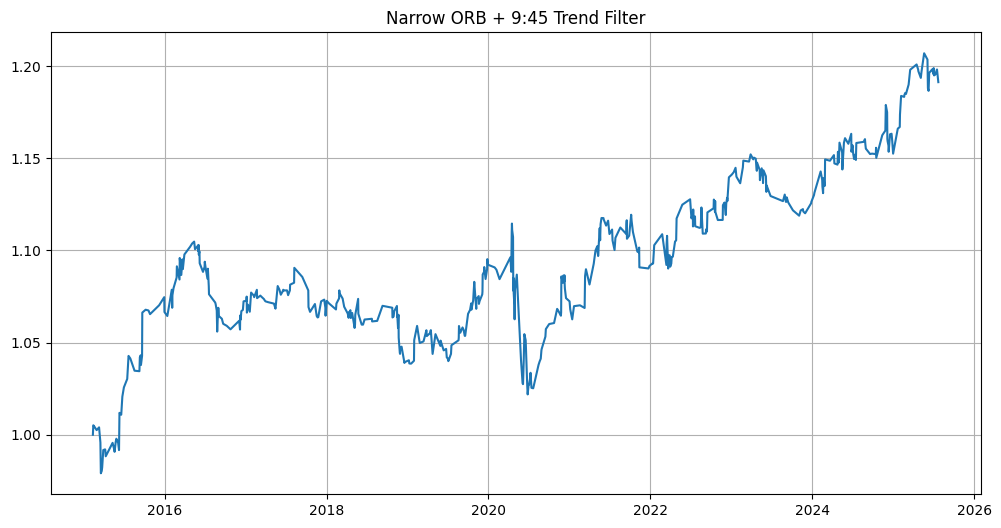

In [6]:
plt.figure(figsize=(12,6))
plt.plot(equity)
plt.title("Narrow ORB + 9:45 Trend Filter")
plt.grid(True)
plt.show()

# Conclusions

## Research Question

Does NIFTY 50 minute-level data exhibit consistent intraday patterns that can be exploited for further research?

## Evidence

- Distinct intraday volatility patterns were observed.
- Market activity varies significantly throughout the trading session.
- Opening and closing periods exhibit higher volatility than midday periods.
- Return distributions are non-uniform across the trading day.
- Multiple potential sources of predictive information were identified.

## Verdict

🟢 Accepted

The NIFTY 50 exhibits clear intraday structure and non-random behavior.

The exploratory analysis identified several promising research directions including:

- Opening Range Analysis
- Morning Momentum
- Gap Analysis
- Volatility Regime Analysis
- Volatility Forecasting

These findings justify further investigation into intraday market behavior.